In [19]:
from typing import TypedDict
from langgraph.graph import StateGraph , START,END

In [20]:
class CalculatorState(TypedDict):
    a:int
    b:int
    sum: int
    product : int
    division : float
    summary : str
    

In [21]:
def addition(state:CalculatorState):
    a= state['a']
    b = state['b']

    return {'sum':a+b}

def product(state:CalculatorState):
    a= state['a']
    b = state['b']

    return {'product':a*b}

def divison(state:CalculatorState):
    a= state['a']
    b = state['b']

    return {'division':a/b}

In [22]:
def summary(state:CalculatorState):
    sum = state['sum']
    product = state['product']
    divison = state['division']

    return {'summary':f'sum is {sum}\nproduct is {product}\ndivision is {divison}'}

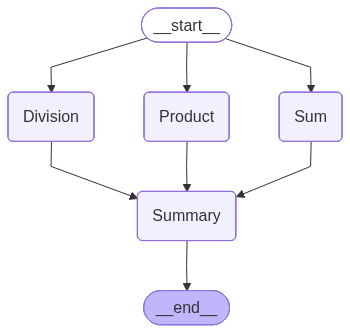

In [23]:
graph = StateGraph(CalculatorState)

graph.add_node('Sum',addition)
graph.add_node('Product',product)
graph.add_node('Division',divison)
graph.add_node("Summary",summary)

graph.add_edge(START,'Sum')
graph.add_edge(START,'Product')
graph.add_edge(START,'Division')
graph.add_edge('Sum','Summary')
graph.add_edge('Product','Summary')
graph.add_edge('Division','Summary')
graph.add_edge('Summary',END)

workflow = graph.compile()

workflow



In [24]:
inital_state = {'a':1,'b':30}

final_state = workflow.invoke(inital_state)

final_state

{'a': 1,
 'b': 30,
 'sum': 31,
 'product': 30,
 'division': 0.03333333333333333,
 'summary': 'sum is 31\nproduct is 30\ndivision is 0.03333333333333333'}

In [25]:
final_state['summary']

'sum is 31\nproduct is 30\ndivision is 0.03333333333333333'